# Airport Security Model: Demonstration and Validation

This notebook introduces the shared airport security model with a baseline example, low-demand and overloaded examples, and basic validation checks. It is a reproducible project entry point, not a repeated-run parameter study.

## Demonstration Settings

| Parameter | Setting |
| --- | --- |
| Arrival probability | Baseline 0.4; low-demand example 0.1; overloaded example 0.9 |
| Checkpoints | 2 |
| Internal waiting capacity | 10 passengers per checkpoint, excluding service |
| Service duration | Fixed at 4 time steps in the three demonstrations |
| Observation length | 500 steps from an empty system |
| Random seed | 42 for each demonstration |

These are **single 500-step demonstrations**. The five analysis notebooks use **5,000 steps and 30 seeds per setting**. Differences between a demonstration's values and a repeated-run mean are expected; they are not directly equivalent estimates. All times are abstract simulation steps, not minutes.

Each checkpoint has its own FIFO internal queue. Passengers wait in an unbounded external FIFO area when the internal queues are full. Each step processes existing service, admits external waiters, generates at most one new arrival, and records queue lengths. No passenger abandons or is rejected.

## Setup

Use the environment described in the project README. Start from the project root or its `notebooks` directory, restart the kernel, and run all cells. Every example imports the same implementation from `src/model.py`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

project_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "src" / "model.py").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Start from the project root or its notebooks directory.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.model import AirportSecurityModel

## Reading the Measures

- **Completed-passenger mean waiting time:** arrival to service start, including internal and external waiting, averaged only over passengers who finish within 500 steps. If no passengers finish, the helper below reports this mean as undefined.
- **Mean internal/external queue:** time-averaged waiting passengers, excluding passengers in service. Internal lengths sum across both checkpoints.
- **Completed passengers:** a count. This is the basic model's `get_results()["throughput"]` value; **throughput rate** divides that count by the observation length.
- **Final external queue:** external waiters at the observation boundary. This is `get_results()["external_waiting"]`, not the time average or a rejection count.
- **Unfinished passengers:** all internal waiters, external waiters, and passengers still in service at the observation boundary.

No warm-up is excluded and no drain-down is added. These finite-horizon statistics are not established steady-state estimates. Read completed-only waiting together with queues and unfinished counts.

In [2]:
def summarize_demo(model, label):
    completed = len(model.completed_passengers)
    internal = sum(len(queue) for queue in model.queues)
    external = len(model.external_waiting)
    in_service = sum(passenger is not None for passenger in model.in_service)
    unfinished = internal + external + in_service
    assert len(model.all_passengers) == completed + unfinished

    waits = [p.waiting_time for p in model.completed_passengers]
    mean_wait = float(np.mean(waits)) if waits else np.nan
    summary = {
        "arrived_passengers": len(model.all_passengers),
        "completed_passengers": completed,
        "mean_completed_wait": mean_wait,
        "mean_internal_queue": float(np.mean(model.queue_length_history)),
        "mean_external_queue": float(np.mean(model.external_waiting_history)),
        "throughput_rate": completed / model.simulation_steps,
        "final_external_queue": external,
        "unfinished_passengers": unfinished,
    }
    print(label)
    print(f"  Arrived passengers: {summary['arrived_passengers']}")
    print(f"  Completed passengers: {completed}")
    wait_label = f"{mean_wait:.3f} time steps" if np.isfinite(mean_wait) else "undefined (no completions)"
    print(f"  Completed-passenger mean wait: {wait_label}")
    print(f"  Mean internal queue: {summary['mean_internal_queue']:.3f} passengers")
    print(f"  Mean external queue: {summary['mean_external_queue']:.3f} passengers")
    print(f"  Throughput rate: {summary['throughput_rate']:.3f} passengers / step")
    print(f"  Final external queue: {external} passengers")
    print(f"  Unfinished passengers: {unfinished} ({internal} internal, {external} external, {in_service} in service)")
    return summary

## Baseline Demonstration

Expected arrival demand is 0.4 passengers per step. Two checkpoints with fixed four-step service have nominal capacity 2 / 4 = 0.5 passengers per step, giving a nominal load ratio of 0.8. Demand is below nominal capacity, but random arrivals can still create waiting. This one short run does not establish steady state.

In [3]:
model = AirportSecurityModel(
    arrival_rate=0.4,
    queue_capacity=10,
    num_checkpoints=2,
    processing_time=4,
    simulation_steps=500,
    processing_time_variation=0,
    seed=42,
)

model.run()

baseline_summary = summarize_demo(model, "Baseline: arrival probability 0.4")

Baseline: arrival probability 0.4
  Arrived passengers: 196
  Completed passengers: 195
  Completed-passenger mean wait: 1.585 time steps
  Mean internal queue: 0.618 passengers
  Mean external queue: 0.000 passengers
  Throughput rate: 0.390 passengers / step
  Final external queue: 0 passengers
  Unfinished passengers: 1 (0 internal, 0 external, 1 in service)


The first plot shows **only internal waiting**, summed across checkpoints; it excludes external waiters and passengers in service. The second plot shows external waiting separately. An empty external area does not imply that nobody waits internally.

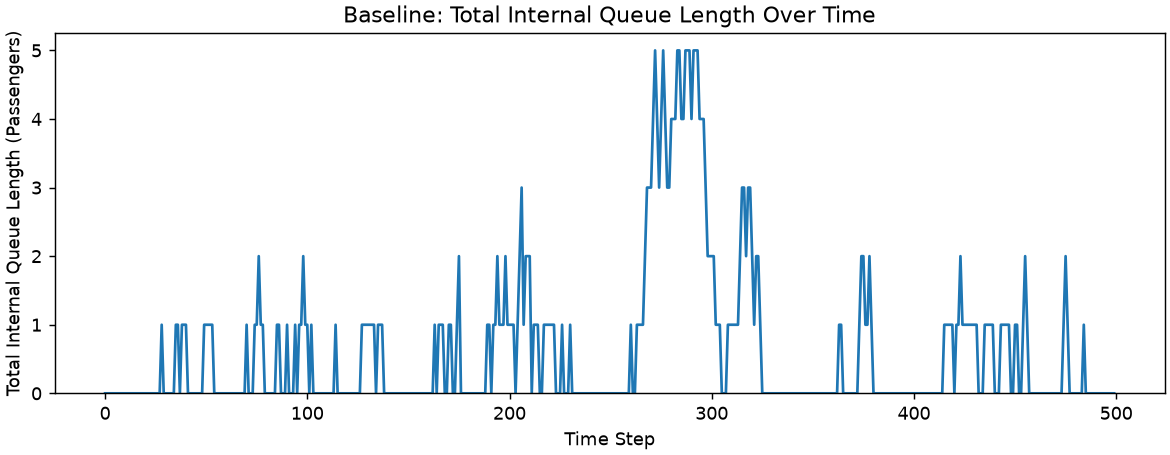

In [4]:
plt.figure(figsize=(9, 3.5), layout="constrained")
plt.plot(model.queue_length_history)
plt.ylim(bottom=0)

plt.xlabel("Time Step")
plt.ylabel("Total Internal Queue Length (Passengers)")
plt.title("Baseline: Total Internal Queue Length Over Time")

plt.show()

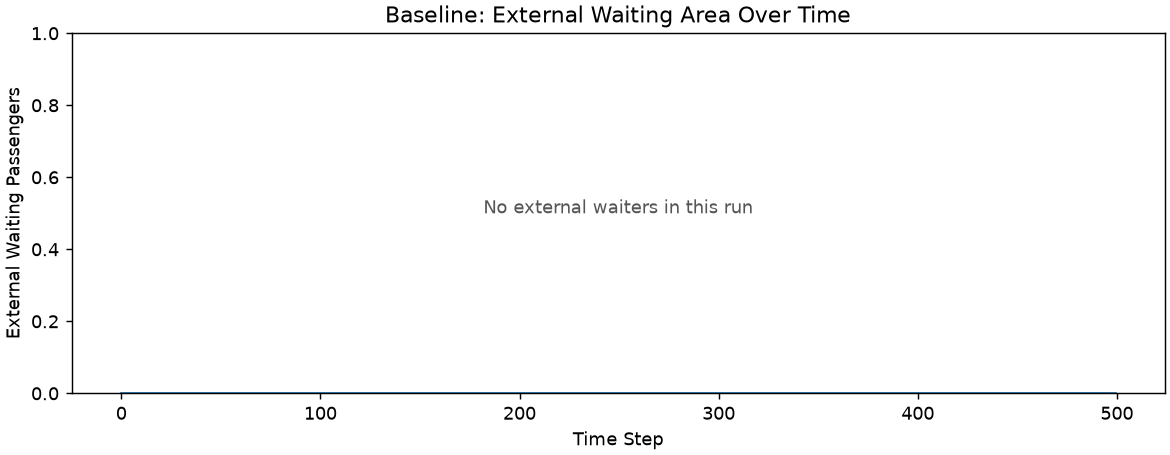

In [5]:
plt.figure(figsize=(9, 3.5), layout="constrained")
plt.plot(model.external_waiting_history)
plt.ylim(0, max(1, max(model.external_waiting_history) * 1.1))
if not any(model.external_waiting_history):
    plt.text(0.5, 0.5, "No external waiters in this run",
             transform=plt.gca().transAxes, ha="center", color="#555555")

plt.xlabel("Time Step")
plt.ylabel("External Waiting Passengers")
plt.title("Baseline: External Waiting Area Over Time")

plt.show()

## Low-Demand Demonstration

Arrival probability 0.1 gives a nominal load ratio of 0.1 / 0.5 = 0.2. Compare its queues and waiting with the baseline. This is a behaviour check using one fixed seed, not evidence about the distribution of results across repeated runs.

In [6]:
low_model = AirportSecurityModel(
    arrival_rate=0.1,
    queue_capacity=10,
    num_checkpoints=2,
    processing_time=4,
    simulation_steps=500,
    processing_time_variation=0,
    seed=42,
)

low_model.run()

low_summary = summarize_demo(low_model, "Low demand: arrival probability 0.1")

Low demand: arrival probability 0.1
  Arrived passengers: 45
  Completed passengers: 45
  Completed-passenger mean wait: 0.067 time steps
  Mean internal queue: 0.006 passengers
  Mean external queue: 0.000 passengers
  Throughput rate: 0.090 passengers / step
  Final external queue: 0 passengers
  Unfinished passengers: 0 (0 internal, 0 external, 0 in service)


## Overloaded Demonstration

Arrival probability 0.9 exceeds the nominal service capacity of 0.5 passengers per step; the nominal load ratio is 1.8. This is **overload**, not merely near-capacity demand or critical load (which would be arrival probability 0.5 with these service settings).

The total internal waiting capacity is 20 passengers. Its queue length can plateau at that bound while the unbounded external queue continues to accumulate passengers. The following plots show both queues on separate axes. A bounded internal queue or throughput near capacity does not demonstrate system stability.

The reported waiting mean excludes all unfinished passengers. It depends on the 500-step observation horizon and is not a stable long-run mean. Extending the run or discarding a warm-up cannot resolve demand exceeding service capacity. Stopping new arrivals and draining the remaining passengers would instead measure waiting for a finite arrival cohort.

In [7]:
high_model = AirportSecurityModel(
    arrival_rate=0.9,
    queue_capacity=10,
    num_checkpoints=2,
    processing_time=4,
    simulation_steps=500,
    processing_time_variation=0,
    seed=42,
)

high_model.run()

high_summary = summarize_demo(high_model, "Overload: arrival probability 0.9")

Overload: arrival probability 0.9
  Arrived passengers: 455
  Completed passengers: 248
  Completed-passenger mean wait: 112.512 time steps
  Mean internal queue: 18.962 passengers
  Mean external queue: 84.162 passengers
  Throughput rate: 0.496 passengers / step
  Final external queue: 185 passengers
  Unfinished passengers: 207 (20 internal, 185 external, 2 in service)


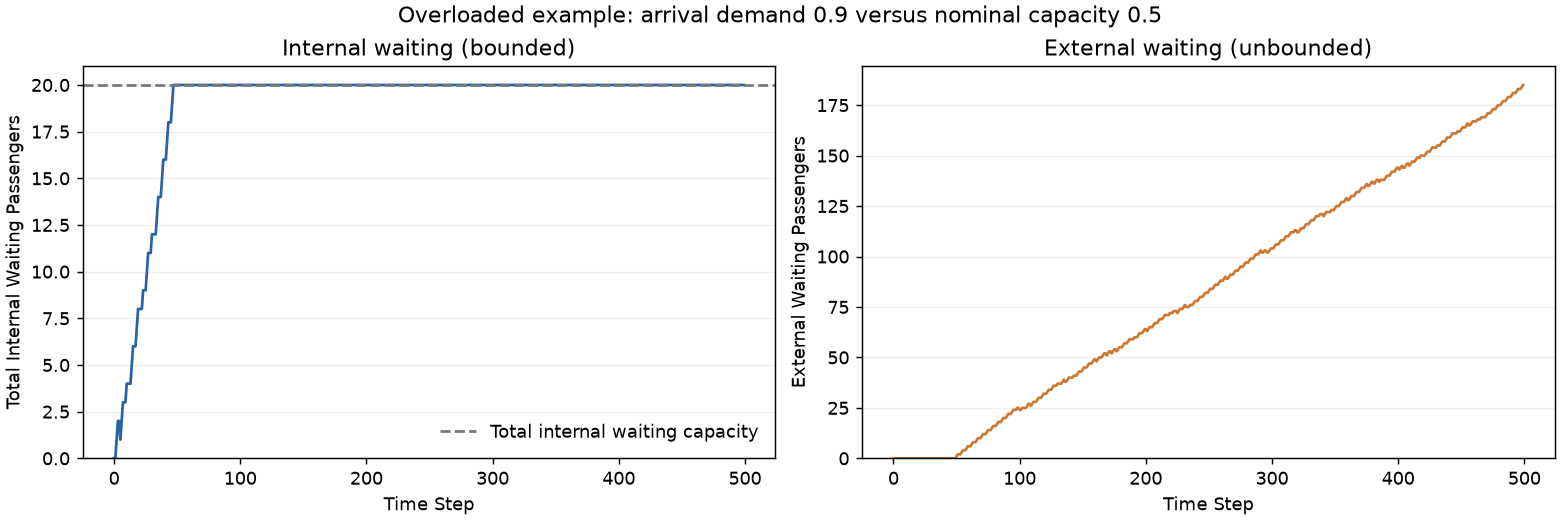

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
fig.suptitle("Overloaded example: arrival demand 0.9 versus nominal capacity 0.5")
axes[0].plot(high_model.queue_length_history, color="#2563A6")
axes[0].axhline(high_model.queue_capacity * high_model.num_checkpoints,
                color="#777777", linestyle="--", label="Total internal waiting capacity")
axes[0].set(title="Internal waiting (bounded)", ylabel="Total Internal Waiting Passengers")
axes[0].legend(frameon=False)
axes[1].plot(high_model.external_waiting_history, color="#CE7833")
axes[1].set(title="External waiting (unbounded)", ylabel="External Waiting Passengers")
for ax in axes:
    ax.set_xlabel("Time Step")
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", alpha=0.2)
plt.show()

### Reproducibility Check
Create two independent models with identical parameters and the same random seed, and verify that their results match.

In [9]:
def run_once(seed):
    model = AirportSecurityModel(
        arrival_rate=0.4,
        queue_capacity=10,
        num_checkpoints=2,
        processing_time=4,
        simulation_steps=500,
        seed=seed,
    )
    model.run()
    return model.get_results()


results_1 = run_once(seed=42)
results_2 = run_once(seed=42)

assert results_1 == results_2
print("Reproducibility check passed.")

Reproducibility check passed.


### Service Duration Validation
Verify that fixed, low-variation, and high-variation scenarios assign integer service durations within the expected bounds.

In [10]:
scenarios = {
    "Fixed": 0,
    "Low variation": 1,
    "High variation": 3,
}

for label, variation in scenarios.items():
    validation_model = AirportSecurityModel(
        arrival_rate=0.4,
        queue_capacity=10,
        num_checkpoints=2,
        processing_time=4,
        processing_time_variation=variation,
        simulation_steps=500,
        seed=42,
    )
    validation_model.run()

    durations = [
        passenger.processing_time
        for passenger in validation_model.all_passengers
        if passenger.processing_time is not None
    ]

    assert durations, "No passengers started service."

    assert all(
        isinstance(duration, int)
        and 4 - variation <= duration <= 4 + variation
        for duration in durations
    ), f"{label}: invalid service duration."

    assert all(
        passenger.completion_time - passenger.service_start_time
        == passenger.processing_time
        for passenger in validation_model.completed_passengers
    ), f"{label}: actual service time does not match assigned duration."

    print(
        f"{label}: validation passed. "
        f"Observed durations: {sorted(set(durations))}"
    )

Fixed: validation passed. Observed durations: [4]
Low variation: validation passed. Observed durations: [3, 4, 5]
High variation: validation passed. Observed durations: [1, 2, 3, 4, 5, 6, 7]


## Continue to the Repeated-Run Experiments

The demonstrations and checks above show basic model behaviour, reproducibility, and service-duration consistency. They do not validate the model against real-airport data or establish statistical significance or steady-state convergence.

Each analysis below uses 5,000 observation steps and 30 seeds per setting. Read waiting alongside queue lengths, throughput, and unfinished counts.

1. [Service-time variation](processing_time_analysis.ipynb): fixed, low, and high variation at equal expected service duration.
2. [Checkpoint count](checkpoint_analysis.ipynb): one to four checkpoints, including an overloaded one-checkpoint case.
3. [Arrival probability](passenger_arrival_rate_analysis.ipynb): demand from 0.2 to the critical-load setting 0.5.
4. [Queue capacity](queue_capacity_analysis.ipynb): whether added internal waiting space changes waiting or mainly its location.
5. [Arrival probability × service-time variation](arrival_variation_analysis.ipynb): nine combinations testing whether the waiting penalty of variability increases near capacity, with descriptive contrasts and exported results.

See the [project README](../README.md) for the full experiment inventory, assumptions, and planned extensions.